# Notebook 05: Visualization Dashboard

This notebook brings together all results from the previous notebooks into a comprehensive set of visualizations:

1. **Allele frequency bar charts** — current vs. NFDS equilibrium target
2. **Compatibility network graph** — genotypes as nodes, compatible crosses as edges
3. **Convergence plot** — allele frequency variance over generations by strategy
4. **Ranked crosses table** — recommended crosses with impact scores
5. **Crossing outcome heatmap** — offspring diversity for each cross

The optimization aims to **accelerate** the natural convergence that NFDS already drives — not to override it. Random mating under NFDS will eventually reach equilibrium; strategic crossing gets there faster.

In [1]:
import itertools
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
from scipy.optimize import minimize

sns.set_style("whitegrid")

# ---------------------------------------------------------------------------
# All utility functions (from Notebooks 01-04)
# ---------------------------------------------------------------------------

def canonical(alleles):
    """Return the canonical (sorted tuple) form of a genotype."""
    return tuple(sorted(alleles))

def allele_frequencies(population, allele_pool=None):
    """Compute allele frequencies (proportion of each S-allele in the population)."""
    counts = Counter()
    total = 0
    for genotype in population:
        for allele in genotype:
            counts[allele] += 1
            total += 1
    freqs = {a: counts[a] / total for a in counts}
    if allele_pool is not None:
        for a in allele_pool:
            if a not in freqs:
                freqs[a] = 0.0
    return dict(sorted(freqs.items()))

def form_gametes(genotype):
    """Return all C(4,2)=6 diploid gametes from a tetraploid genotype."""
    return list(itertools.combinations(genotype, 2))

def is_compatible(maternal_genotype, pollen_gamete):
    """Check SI compatibility: True if pollen shares no alleles with maternal plant."""
    maternal_alleles = set(maternal_genotype)
    return not any(a in maternal_alleles for a in pollen_gamete)

def cross(parent_a, parent_b):
    """Compute offspring genotype probabilities for a directed cross (maternal x pollen)."""
    maternal_gametes = form_gametes(parent_a)
    paternal_gametes = form_gametes(parent_b)
    compatible_paternal = [g for g in paternal_gametes if is_compatible(parent_a, g)]
    if not compatible_paternal:
        return {}
    offspring_counts = Counter()
    total_combinations = len(maternal_gametes) * len(compatible_paternal)
    for mg in maternal_gametes:
        for pg in compatible_paternal:
            offspring_genotype = canonical(mg + pg)
            offspring_counts[offspring_genotype] += 1
    return {g: count / total_combinations for g, count in sorted(offspring_counts.items())}

def crossing_compatibility(parent_a, parent_b):
    """Fraction of pollen gametes that pass SI (0.0 = incompatible, 1.0 = fully compatible)."""
    paternal_gametes = form_gametes(parent_b)
    compatible = sum(1 for g in paternal_gametes if is_compatible(parent_a, g))
    return compatible / len(paternal_gametes)

def sample_offspring(parent_a, parent_b):
    """Sample a single offspring from a cross (None if incompatible)."""
    offspring_dist = cross(parent_a, parent_b)
    if not offspring_dist:
        return None
    genotypes = list(offspring_dist.keys())
    probs = list(offspring_dist.values())
    idx = np.random.choice(len(genotypes), p=probs)
    return genotypes[idx]

def simulate_generation(population, n_offspring=None, crossing_plan=None):
    """Simulate one generation using random mating or a weighted crossing plan."""
    if n_offspring is None:
        n_offspring = len(population)
    next_gen = []
    if crossing_plan is not None:
        indices = list(range(len(crossing_plan)))
        weights = np.array([w for _, _, w in crossing_plan])
        weights = weights / weights.sum()
        attempts = 0
        while len(next_gen) < n_offspring and attempts < n_offspring * 20:
            idx = np.random.choice(indices, p=weights)
            mi, pi, _ = crossing_plan[idx]
            child = sample_offspring(population[mi], population[pi])
            if child is not None:
                next_gen.append(child)
            attempts += 1
    else:
        attempts = 0
        n = len(population)
        while len(next_gen) < n_offspring and attempts < n_offspring * 20:
            i, j = random.sample(range(n), 2)
            child = sample_offspring(population[i], population[j])
            if child is not None:
                next_gen.append(child)
            attempts += 1
    return next_gen

def distance_from_equilibrium(population, allele_pool):
    """Compute variance, chi-squared, and KL divergence from uniform allele frequencies."""
    freqs = allele_frequencies(population, allele_pool)
    n = len(allele_pool)
    target = 1.0 / n
    freq_values = np.array([freqs[a] for a in sorted(allele_pool)])
    variance = float(np.var(freq_values))
    chi_squared = float(np.sum((freq_values - target) ** 2 / target))
    eps = 1e-12
    freq_safe = np.maximum(freq_values, eps)
    kl_div = float(np.sum(freq_safe * np.log(freq_safe / target)))
    return {"variance": variance, "chi_squared": chi_squared, "kl_divergence": kl_div}

# ---------------------------------------------------------------------------
# Adaptive strategy helpers (re-called per generation in simulation loop)
# ---------------------------------------------------------------------------

def enumerate_compatible_crosses(pop, allele_pool):
    """Enumerate all SI-compatible directed crosses and build allele effect matrix."""
    compatible_crosses = []
    cross_allele_effects = []
    n_pop = len(pop)
    for i in range(n_pop):
        for j in range(n_pop):
            if i == j:
                continue
            compat = crossing_compatibility(pop[i], pop[j])
            if compat > 0:
                offspring_dist = cross(pop[i], pop[j])
                expected_freqs = {a: 0.0 for a in allele_pool}
                for genotype, prob in offspring_dist.items():
                    for allele in genotype:
                        if allele in expected_freqs:
                            expected_freqs[allele] += prob / 4.0
                compatible_crosses.append((i, j, compat))
                cross_allele_effects.append(expected_freqs)
    allele_effect_matrix = np.array([
        [effects[a] for a in sorted(allele_pool)]
        for effects in cross_allele_effects
    ])
    return compatible_crosses, allele_effect_matrix


def compute_greedy_weights(pop, allele_pool, compatible_crosses, allele_effect_matrix):
    """Compute greedy crossing weights that boost underrepresented alleles."""
    target_freq = 1.0 / len(allele_pool)
    current_freqs = allele_frequencies(pop, allele_pool)
    freq_array = np.array([current_freqs[a] for a in sorted(allele_pool)])
    n_crosses = len(compatible_crosses)
    greedy_scores = np.zeros(n_crosses)
    for k in range(n_crosses):
        deficit = target_freq - freq_array
        boost = allele_effect_matrix[k] - target_freq
        greedy_scores[k] = np.sum(np.maximum(deficit, 0) * np.maximum(boost, 0))
    if greedy_scores.sum() > 0:
        return greedy_scores / greedy_scores.sum()
    return np.ones(n_crosses) / n_crosses


def compute_optimal_weights(compatible_crosses, allele_effect_matrix, allele_pool, maxiter=1000):
    """Run scipy L-BFGS-B optimization to find weights minimizing chi-squared distance.

    Uses an analytical gradient to avoid finite-difference overhead, which is
    critical for large populations (e.g. 14K crosses in the real dataset).
    """
    target_freq = 1.0 / len(allele_pool)
    n_crosses = len(compatible_crosses)
    def _fitness_and_grad(weights):
        w = np.abs(weights)
        w_sum = w.sum()
        if w_sum < 1e-12:
            return 1e6, np.zeros(n_crosses)
        w_norm = w / w_sum
        expected = w_norm @ allele_effect_matrix  # (n_alleles,)
        diff = expected - target_freq
        chi_sq = float(np.sum(diff ** 2 / target_freq))
        # Analytical gradient through the normalization
        residuals = 2 * diff / target_freq  # (n_alleles,)
        g = allele_effect_matrix @ residuals  # (n_crosses,)
        grad = (g - np.dot(w_norm, g)) / w_sum
        return chi_sq, grad
    w0 = np.ones(n_crosses) / n_crosses
    result = minimize(
        _fitness_and_grad, w0, method="L-BFGS-B",
        jac=True,
        bounds=[(0, 1)] * n_crosses,
        options={"maxiter": maxiter, "ftol": 1e-12},
    )
    optimal_weights = np.abs(result.x)
    optimal_weights = optimal_weights / optimal_weights.sum()
    return optimal_weights, result

print("All utilities loaded.")

All utilities loaded.


In [2]:
# ---------------------------------------------------------------------------
# Population and precomputation
# ---------------------------------------------------------------------------
# This cell reproduces the setup from Notebook 04 so this notebook is
# self-contained. It: (1) defines the skewed population, (2) enumerates
# all SI-compatible crosses, (3) runs scipy optimization, and (4) computes
# greedy weights. All results feed into the visualizations below.

allele_pool = list(range(1, 9))

population = [
    (1, 1, 2, 3),
    (1, 2, 2, 4),
    (1, 1, 3, 5),
    (2, 2, 3, 4),
    (1, 2, 5, 6),
    (1, 3, 4, 5),
    (2, 3, 3, 6),
    (1, 1, 2, 6),
    (1, 2, 4, 4),
    (2, 3, 5, 6),
    (1, 1, 4, 5),
    (1, 2, 3, 3),
    (2, 2, 5, 6),
    (1, 3, 4, 6),
    (1, 2, 2, 5),
    (1, 1, 3, 7),
    (2, 4, 5, 8),
    (1, 3, 6, 7),
    (2, 3, 4, 8),
    (1, 2, 7, 8),
]

# Step 1: Enumerate compatible crosses using helper
compatible_crosses, allele_effect_matrix = enumerate_compatible_crosses(population, allele_pool)
n_crosses = len(compatible_crosses)
n_pop = len(population)
target_freq = 1.0 / len(allele_pool)

# Step 2: Fitness function (standalone, used by downstream visualization cells)
def fitness_function(weights):
    w = np.abs(weights)
    w_sum = w.sum()
    if w_sum < 1e-12:
        return 1e6
    w = w / w_sum
    expected_freqs = w @ allele_effect_matrix
    return float(np.sum((expected_freqs - target_freq) ** 2 / target_freq))

# Step 3: Scipy optimization using helper
optimal_weights, result = compute_optimal_weights(
    compatible_crosses, allele_effect_matrix, allele_pool
)

# Step 4: Greedy weights using helper
greedy_weights = compute_greedy_weights(
    population, allele_pool, compatible_crosses, allele_effect_matrix
)

print(f"Setup complete: {n_pop} individuals, {len(allele_pool)} alleles, {n_crosses} compatible crosses")

Setup complete: 20 individuals, 8 alleles, 261 compatible crosses


## 1. Allele Frequency Distribution: Current vs. NFDS Equilibrium Target

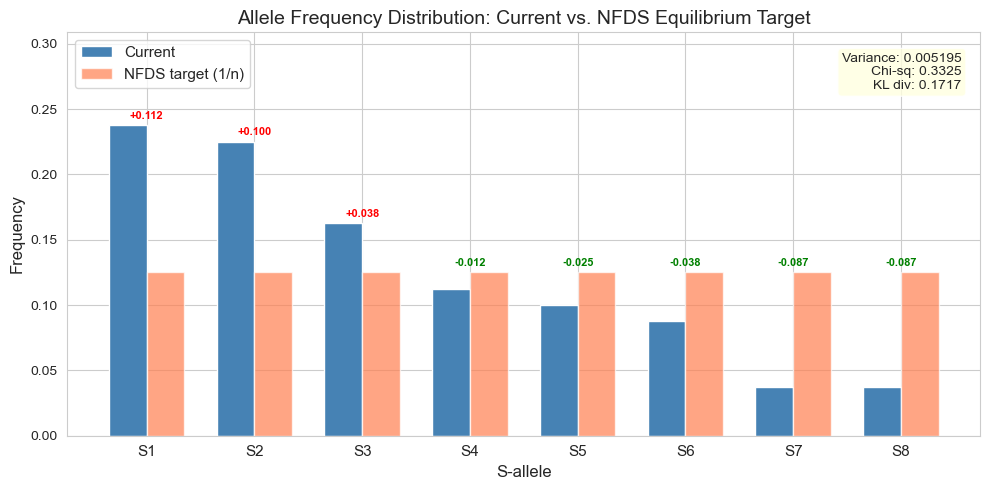

In [3]:
# Allele frequency bar chart: current population vs. NFDS equilibrium target.
# Deviation annotations above each pair show how far each allele is from target:
#   Red (+) = overrepresented allele (too common, NFDS will reduce it)
#   Green (-) = underrepresented allele (too rare, NFDS will boost it)
# The distance metrics in the corner quantify overall population-level imbalance.
freqs = allele_frequencies(population, allele_pool)
alleles = list(freqs.keys())
freq_values = list(freqs.values())

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(alleles))
width = 0.35

bars1 = ax.bar(x - width/2, freq_values, width, label="Current", color="steelblue", edgecolor="white")
bars2 = ax.bar(x + width/2, [target_freq] * len(alleles), width, label="NFDS target (1/n)",
               color="coral", alpha=0.7, edgecolor="white")

# Annotate each allele's deviation from the uniform target
for i, (curr, tgt) in enumerate(zip(freq_values, [target_freq] * len(alleles))):
    diff = curr - tgt
    color = "red" if diff > 0 else "green"
    ax.annotate(f"{diff:+.3f}", xy=(x[i], max(curr, tgt) + 0.005),
                ha="center", fontsize=8, color=color, fontweight="bold")

ax.set_xlabel("S-allele", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.set_title("Allele Frequency Distribution: Current vs. NFDS Equilibrium Target", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([f"S{a}" for a in alleles], fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, max(freq_values) * 1.3)

# Display all three distance metrics for a complete picture of disequilibrium
d = distance_from_equilibrium(population, allele_pool)
ax.text(0.98, 0.95,
        f"Variance: {d['variance']:.6f}\nChi-sq: {d['chi_squared']:.4f}\nKL div: {d['kl_divergence']:.4f}",
        transform=ax.transAxes, ha="right", va="top",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8), fontsize=10)

plt.tight_layout()
plt.show()

## 2. Compatibility Network Graph

Nodes represent **unique genotypes** in the population. Edges connect compatible crossing pairs. Edge thickness reflects the **optimal crossing weight** (thicker = higher priority).

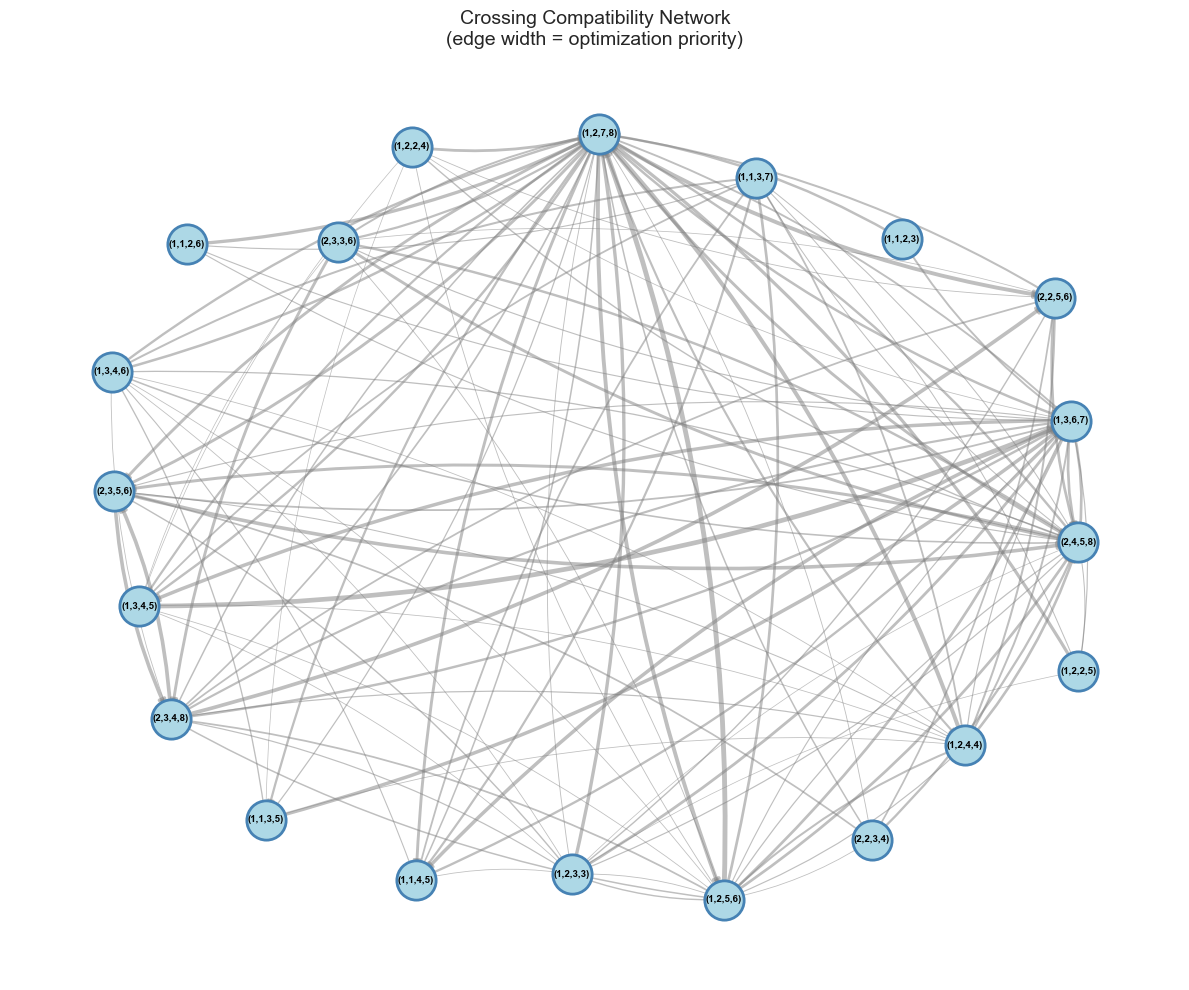

Nodes (unique genotypes): 20
Edges (compatible crosses): 118


In [4]:
# Compatibility network: each node is a unique genotype in the population,
# each directed edge represents an SI-compatible cross. Edge thickness is
# proportional to the optimal crossing weight — thicker edges are higher-priority
# crosses for accelerating convergence to NFDS equilibrium.
# Isolated nodes (if any) would indicate genotypes with no compatible mates.

# Build directed graph from unique genotypes
unique_genotypes = list(set(population))
genotype_labels = {g: f"({','.join(str(a) for a in g)})" for g in unique_genotypes}

G = nx.DiGraph()
for g in unique_genotypes:
    G.add_node(genotype_labels[g])

# Aggregate optimal weights per genotype pair (multiple individuals may share
# the same genotype, so we sum their weights)
edge_weights = {}
for k in range(n_crosses):
    i, j, compat = compatible_crosses[k]
    ga = population[i]
    gb = population[j]
    key = (genotype_labels[ga], genotype_labels[gb])
    if key not in edge_weights:
        edge_weights[key] = 0.0
    edge_weights[key] += optimal_weights[k]

# Only draw edges with meaningful weight to keep the graph readable
for (src, dst), weight in edge_weights.items():
    if weight > 1e-4:
        G.add_edge(src, dst, weight=weight)

fig, ax = plt.subplots(figsize=(12, 10))

pos = nx.spring_layout(G, seed=42, k=2)

# Draw nodes (genotypes) and labels
nx.draw_networkx_nodes(G, pos, node_size=800, node_color="lightblue",
                       edgecolors="steelblue", linewidths=2, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=7, font_weight="bold", ax=ax)

# Draw edges with width scaled by optimization weight
edges = G.edges(data=True)
if edges:
    weights = [d["weight"] * 50 for _, _, d in edges]  # Scale for visibility
    max_w = max(weights) if weights else 1
    nx.draw_networkx_edges(G, pos, width=[w / max_w * 3 + 0.5 for w in weights],
                           alpha=0.5, edge_color="gray",
                           connectionstyle="arc3,rad=0.1",
                           arrows=True, arrowsize=10, ax=ax)

ax.set_title("Crossing Compatibility Network\n(edge width = optimization priority)", fontsize=14)
ax.axis("off")

plt.tight_layout()
plt.show()

print(f"Nodes (unique genotypes): {G.number_of_nodes()}")
print(f"Edges (compatible crosses): {G.number_of_edges()}")

## 3. Convergence Plot: Strategy Comparison

Each generation, adaptive strategies **recompute** their crossing plan from the current population — ensuring weights and indices stay valid as the population evolves. Random mating is the baseline (NFDS only).

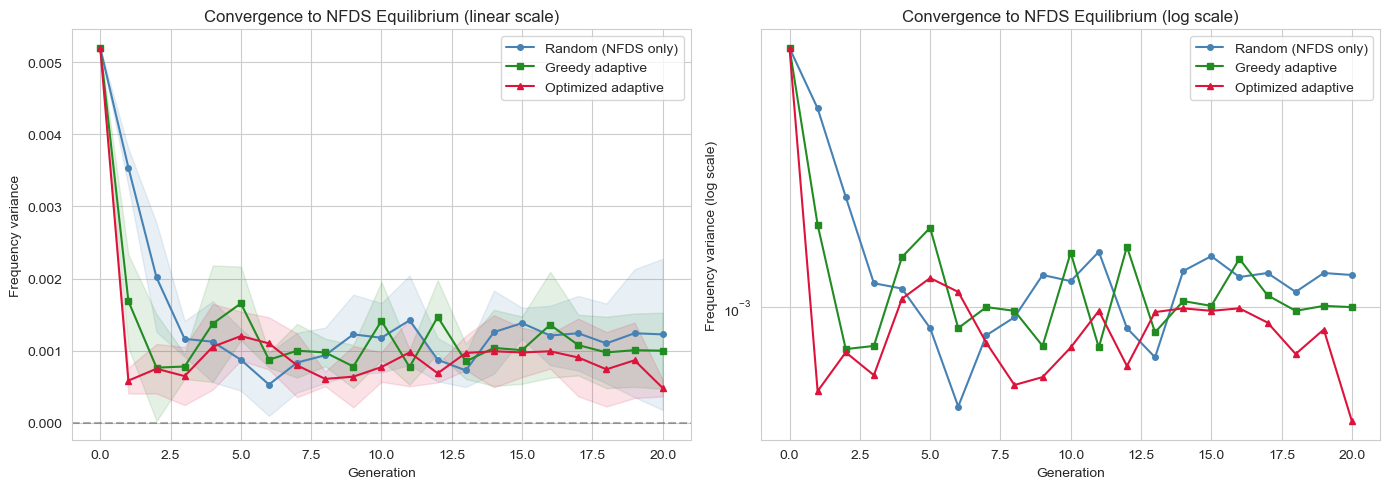


Final variance by strategy:
  Random (NFDS only): 0.001227
  Greedy adaptive:    0.001000
  Optimized adaptive: 0.000484


In [5]:
# Multi-generation convergence comparison across three crossing strategies.
# Left panel (linear scale): shows the absolute rate of variance decline.
# Right panel (log scale): reveals differences in convergence rate at small
# variance values where linear scale compresses differences. Exponential
# convergence appears as a straight line on log scale.
np.random.seed(123)
random.seed(123)

n_generations = 20
n_trials = 5

def run_strategy(pop, allele_pool, n_gen, strategy="random", n_trials=5, opt_maxiter=1000):
    """Run an adaptive strategy over multiple generations, averaging across stochastic trials."""
    all_variances = np.zeros((n_trials, n_gen + 1))
    for trial in range(n_trials):
        current_pop = list(pop)
        for gen in range(n_gen + 1):
            d = distance_from_equilibrium(current_pop, allele_pool)
            all_variances[trial, gen] = d["variance"]
            if gen < n_gen:
                if strategy == "random":
                    current_pop = simulate_generation(current_pop)
                else:
                    cc, aem = enumerate_compatible_crosses(current_pop, allele_pool)
                    if strategy == "greedy":
                        weights = compute_greedy_weights(current_pop, allele_pool, cc, aem)
                    elif strategy == "optimized":
                        weights, _ = compute_optimal_weights(cc, aem, allele_pool, maxiter=opt_maxiter)
                    else:
                        raise ValueError(f"Unknown strategy: {strategy}")
                    plan = [
                        (cc[k][0], cc[k][1], weights[k])
                        for k in range(len(cc))
                        if weights[k] > 1e-6
                    ]
                    current_pop = simulate_generation(current_pop, crossing_plan=plan)
    return all_variances.mean(axis=0), all_variances.std(axis=0)

random_mean, random_std = run_strategy(population, allele_pool, n_generations, "random", n_trials)
greedy_mean, greedy_std = run_strategy(population, allele_pool, n_generations, "greedy", n_trials)
optimal_mean, optimal_std = run_strategy(population, allele_pool, n_generations, "optimized", n_trials)

generations = np.arange(n_generations + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale — good for seeing overall convergence shape
for mean, std, label, color, marker in [
    (random_mean, random_std, "Random (NFDS only)", "steelblue", "o"),
    (greedy_mean, greedy_std, "Greedy adaptive", "forestgreen", "s"),
    (optimal_mean, optimal_std, "Optimized adaptive", "crimson", "^"),
]:
    ax1.plot(generations, mean, f"-{marker}", color=color, markersize=4, label=label)
    ax1.fill_between(generations, mean - std, mean + std, alpha=0.12, color=color)

ax1.axhline(y=0, color="black", linestyle="--", alpha=0.3)
ax1.set_xlabel("Generation")
ax1.set_ylabel("Frequency variance")
ax1.set_title("Convergence to NFDS Equilibrium (linear scale)")
ax1.legend()

# Log scale — reveals convergence rate differences at small variance values
for mean, std, label, color, marker in [
    (random_mean, random_std, "Random (NFDS only)", "steelblue", "o"),
    (greedy_mean, greedy_std, "Greedy adaptive", "forestgreen", "s"),
    (optimal_mean, optimal_std, "Optimized adaptive", "crimson", "^"),
]:
    ax2.semilogy(generations, np.maximum(mean, 1e-8), f"-{marker}", color=color, markersize=4, label=label)

ax2.set_xlabel("Generation")
ax2.set_ylabel("Frequency variance (log scale)")
ax2.set_title("Convergence to NFDS Equilibrium (log scale)")
ax2.legend()

plt.tight_layout()
plt.show()

print("\nFinal variance by strategy:")
print(f"  Random (NFDS only): {random_mean[-1]:.6f}")
print(f"  Greedy adaptive:    {greedy_mean[-1]:.6f}")
print(f"  Optimized adaptive: {optimal_mean[-1]:.6f}")

## 4. Ranked Table of Recommended Crosses

These crosses accelerate convergence toward NFDS equilibrium by boosting rare allele frequencies. Impact score measures how much a given cross moves offspring allele frequencies toward the uniform target.

In [6]:
# Ranked table of recommended crosses, sorted by impact score.
# Impact score = how much a cross moves offspring allele frequencies toward
# NFDS equilibrium compared to the current population's chi-squared distance.
#   Positive impact = offspring from this cross are closer to equilibrium
#   Higher impact = more beneficial cross for equalizing allele frequencies
# Practitioners should prioritize crosses at the top of this list.
cross_rows = []
for k in range(n_crosses):
    i, j, compat = compatible_crosses[k]
    expected_freqs = allele_effect_matrix[k]
    # Chi-squared of this cross's expected offspring frequencies vs. uniform target
    chi_sq = float(np.sum((expected_freqs - target_freq) ** 2 / target_freq))

    # Impact: how much better this cross is vs. the current population state.
    # Positive means the cross produces offspring closer to equilibrium.
    baseline_chi = d["chi_squared"]
    impact = baseline_chi - chi_sq

    cross_rows.append({
        "Rank": 0,
        "Maternal": str(population[i]),
        "Pollen donor": str(population[j]),
        "Compatibility": f"{compat:.0%}",
        "Offspring chi-sq": chi_sq,
        "Impact score": impact,
        "Optimal weight": optimal_weights[k],
    })

df_ranked = pd.DataFrame(cross_rows)
df_ranked = df_ranked.sort_values("Impact score", ascending=False).reset_index(drop=True)
df_ranked["Rank"] = range(1, len(df_ranked) + 1)

print("Top 20 Recommended Crosses (by impact toward NFDS equilibrium):")
print()
display_cols = ["Rank", "Maternal", "Pollen donor", "Compatibility", "Impact score", "Optimal weight"]
print(df_ranked[display_cols].head(20).to_string(index=False, float_format="{:.4f}".format))

Top 20 Recommended Crosses (by impact toward NFDS equilibrium):

 Rank     Maternal Pollen donor Compatibility  Impact score  Optimal weight
    1 (1, 3, 6, 7) (2, 4, 5, 8)          100%        0.3325          0.0138
    2 (2, 4, 5, 8) (1, 3, 6, 7)          100%        0.3325          0.0138
    3 (2, 3, 4, 8) (1, 3, 6, 7)           50%        0.1658          0.0121
    4 (2, 4, 5, 8) (1, 3, 4, 6)           50%        0.1658          0.0040
    5 (1, 3, 4, 5) (1, 2, 7, 8)           50%        0.1658          0.0119
    6 (1, 2, 5, 6) (2, 3, 4, 8)           50%        0.1658          0.0074
    7 (1, 3, 4, 6) (2, 4, 5, 8)           50%        0.1658          0.0063
    8 (2, 3, 5, 6) (1, 2, 7, 8)           50%        0.1658          0.0153
    9 (1, 2, 7, 8) (1, 3, 4, 5)           50%        0.1658          0.0106
   10 (1, 2, 7, 8) (2, 3, 5, 6)           50%        0.1658          0.0151
   11 (2, 3, 4, 8) (1, 2, 5, 6)           50%        0.1658          0.0056
   12 (1, 2, 7, 8) (1, 

## 5. Crossing Outcome Heatmap

For a subset of genotypes, show the number of unique offspring genotypes produced by each cross and the compatibility level.

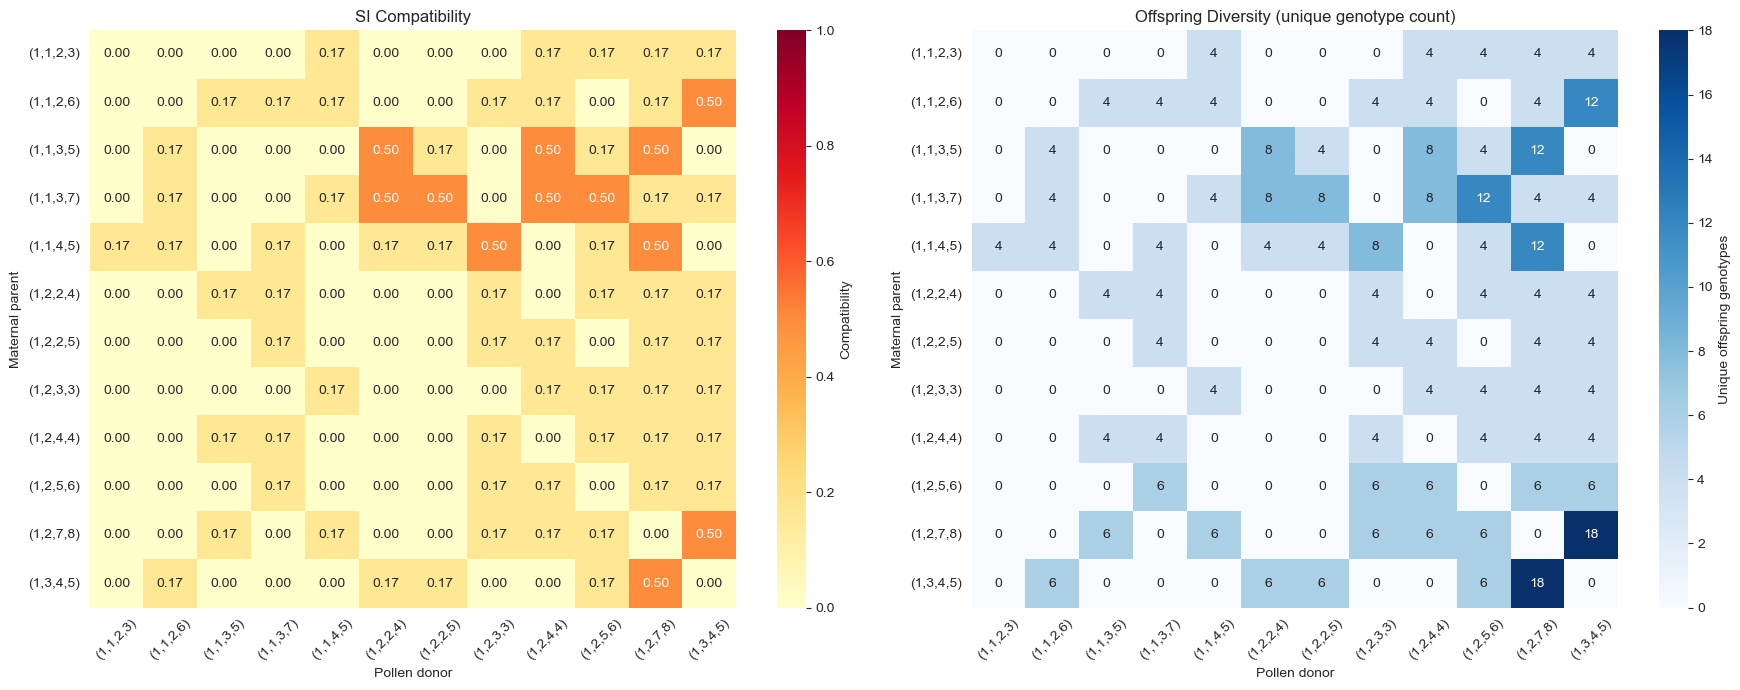

In [7]:
# Dual heatmaps for a subset of genotypes (first 12 unique genotypes).
# Left heatmap — SI Compatibility: fraction of pollen gametes accepted.
#   - Diagonal = 0 (self-incompatibility)
#   - Higher values = fewer shared alleles between parents
#   - Asymmetric because SI is evaluated against the maternal parent
# Right heatmap — Offspring Diversity: number of unique offspring genotypes.
#   - More diverse offspring = wider range of allele combinations in next generation
#   - Crosses with high compatibility tend to produce more diverse offspring
#   - Zero offspring count = fully incompatible cross (no pollen accepted)
unique_genos = sorted(set(population))[:12]
n_g = len(unique_genos)

compat_grid = np.zeros((n_g, n_g))
offspring_count_grid = np.zeros((n_g, n_g))

for i, ga in enumerate(unique_genos):
    for j, gb in enumerate(unique_genos):
        if i == j:
            continue
        compat_grid[i, j] = crossing_compatibility(ga, gb)
        outcomes = cross(ga, gb)
        offspring_count_grid[i, j] = len(outcomes)

labels = [f"({','.join(str(a) for a in g)})" for g in unique_genos]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Left: compatibility heatmap (0 to 1 scale)
sns.heatmap(compat_grid, annot=True, fmt=".2f", xticklabels=labels, yticklabels=labels,
            cmap="YlOrRd", vmin=0, vmax=1, ax=ax1, cbar_kws={"label": "Compatibility"})
ax1.set_xlabel("Pollen donor")
ax1.set_ylabel("Maternal parent")
ax1.set_title("SI Compatibility")
ax1.tick_params(axis="x", rotation=45)
ax1.tick_params(axis="y", rotation=0)

# Right: offspring diversity heatmap (count of unique genotypes)
sns.heatmap(offspring_count_grid, annot=True, fmt=".0f", xticklabels=labels, yticklabels=labels,
            cmap="Blues", ax=ax2, cbar_kws={"label": "Unique offspring genotypes"})
ax2.set_xlabel("Pollen donor")
ax2.set_ylabel("Maternal parent")
ax2.set_title("Offspring Diversity (unique genotype count)")
ax2.tick_params(axis="x", rotation=45)
ax2.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()